From,To,Total Distance,Path
A,F,13,A ➔ C ➔ B ➔ D ➔ E ➔ F


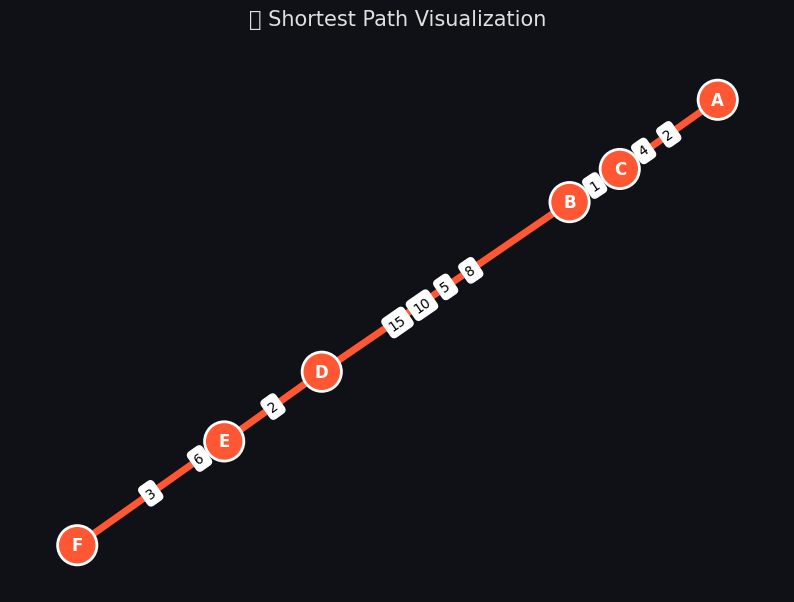

In [5]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files
import io

# --- 1. Core Logic (Dijkstra) ---
def dijkstra(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    priority_queue = [(0, start)]
    previous_nodes = {node: None for node in graph}

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous_nodes[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))
    return distances, previous_nodes

def reconstruct_path(previous, start, end):
    path = []
    current = end
    while current is not None:
        path.append(current)
        current = previous[current]
    path.reverse()
    return path if path and path[0] == start else []

# --- 2. Visualization & UI Functions ---
def draw_styled_graph(graph, path=[]):
    G = nx.Graph()
    for u in graph:
        for v, w in graph[u].items():
            G.add_edge(u, v, weight=w)

    plt.figure(figsize=(10, 7))
    pos = nx.kamada_kawai_layout(G)  # Layout ที่ดูสมดุลกว่า spring_layout

    # วาดเส้นพื้นฐาน
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.3, edge_color='gray', style='dashed')

    # วาดเส้นทางที่สั้นที่สุด (ถ้ามี)
    if path:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=5, edge_color='#FF5733')

    # วาดโหนด
    node_colors = ['#FF5733' if n in path else '#3498DB' for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors, edgecolors='white', linewidths=2)

    # วาด Label
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', font_color='white')
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

    plt.title("📍 Shortest Path Visualization", fontsize=15, pad=20)
    plt.axis('off')
    plt.show()

# --- 3. Main Interface Logic ---
graph_data = {}

def on_upload_change(change):
    global graph_data
    if not change['new']: return

    # อ่านไฟล์ที่อัปโหลด
    content = list(change['new'].values())[0]['content']
    lines = content.decode('utf-8').splitlines()

    new_graph = {}
    try:
        num_edges = int(lines[0].split('#')[0].strip())
        for i in range(1, num_edges + 1):
            u, v, w = lines[i].split('#')[0].split()
            w = int(w)
            if u not in new_graph: new_graph[u] = {}
            if v not in new_graph: new_graph[v] = {}
            new_graph[u][v] = w
            new_graph[v][u] = w

        graph_data = new_graph
        update_dropdowns(list(graph_data.keys()))
        print("✅ โหลดข้อมูลกราฟสำเร็จ!")
    except Exception as e:
        print(f"❌ รูปแบบไฟล์ไม่ถูกต้อง: {e}")

def run_dijkstra_ui(b):
    clear_output(wait=True)
    display(ui_container)

    start = start_dd.value
    end = end_dd.value

    if not graph_data:
        print("⚠️ กรุณาอัปโหลดไฟล์ก่อน")
        return

    distances, previous = dijkstra(graph_data, start)
    path = reconstruct_path(previous, start, end)

    if distances[end] == float('inf'):
        print(f"❌ ไม่พบเส้นทางจาก {start} ไป {end}")
    else:
        # แสดงผลสรุปในรูปแบบตารางสวยๆ
        res_df = pd.DataFrame({
            "From": [start], "To": [end],
            "Total Distance": [distances[end]],
            "Path": [" ➔ ".join(path)]
        })
        display(res_df.style.hide(axis='index').set_properties(**{'background-color': '#f9f9f9', 'color': 'black', 'border-color': 'silver'}))
        draw_styled_graph(graph_data, path)

# --- 4. UI Components ---
upload_btn = widgets.FileUpload(accept='.txt', multiple=False, description="📂 อัปโหลดไฟล์ .txt")
upload_btn.observe(on_upload_change, names='value')

start_dd = widgets.Dropdown(description='จุดเริ่มต้น:')
end_dd = widgets.Dropdown(description='จุดปลายทาง:')
run_btn = widgets.Button(description="🚀 คำนวณเส้นทาง", button_style='success')
run_btn.on_click(run_dijkstra_ui)

def update_dropdowns(nodes):
    start_dd.options = sorted(nodes)
    end_dd.options = sorted(nodes)

ui_container = widgets.VBox([
    widgets.HTML("<h2>🛠 Dijkstra Path Finder</h2>"),
    upload_btn,
    widgets.HBox([start_dd, end_dd, run_btn])
])

display(ui_container)